# EDA — Componente A: el panel unificado (`panel_union`)

Análisis exploratorio de `data/processed/panel_union.parquet`: **~21 000 filas**
(departamento × campaña × cultivo), **312 departamentos** de 15 provincias,
campañas **1981/82 – 2024/25**, soja y maíz.

Responde las preguntas que definen el diseño del pipeline (los experimentos con
modelos están en `experiments/`):

1. ¿Qué cobertura y calidad tiene el panel?
2. ¿Cómo se comporta el **rinde** (el objetivo) en el tiempo y en el espacio?
3. ¿La etiqueta proxy **`z_rinde < −1.5`** marca lo que debería marcar?
4. ¿Cuánta señal climática hay para detectar esas anomalías?
5. ¿Qué pasa entre los splits temporales (train/val/test)?

In [1]:
import os, sys, warnings
if os.path.basename(os.getcwd()) == "eda":
    os.chdir("..")                      # eda/ → componente_a/ (rutas del proyecto)
sys.path.insert(0, os.getcwd())
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

from src.config import ExperimentConfig
from src import data as cdata

cfg = ExperimentConfig()
panel = cdata.load_panel(cfg)                 # dedup + clave [provincia, departamento]
panel = cdata.compute_z_rinde(panel, cfg)     # la MISMA etiqueta que usan los modelos
panel["split"] = panel.campania_inicio.map(
    lambda y: "train" if y <= 2017 else ("val" if y <= 2020 else "test"))
print("shape:", panel.shape)
panel.head(3)

[data] dedup panel: 28683 → 21418 filas (7265 duplicados espurios por lat/lon eliminados)


shape: (21418, 73)


,cultivo,campania_inicio,campania,provincia,departamento,sup_sembrada_ha,sup_cosechada_ha,produccion_tn,rinde_kgha,region,...,ws2m_nov,ws2m_oct,ws2m_sep,ndvi_mean,ndvi_min,ndvi_max,ndvi_anomalia_pct,z_rinde,anomalia,split
9307,maiz,1981,1981/82,BUENOS AIRES,25 De Mayo,40000,39500.0,142200.0,3600.0,resto,...,2.850667,2.612903,2.743667,NaN,NaN,NaN,NaN,NaN,0,train
9603,maiz,1982,1982/83,BUENOS AIRES,25 De Mayo,41000,39500.0,152100.0,3851.0,resto,...,2.692000,3.007097,3.094000,NaN,NaN,NaN,NaN,NaN,0,train
9899,maiz,1983,1983/84,BUENOS AIRES,25 De Mayo,25000,23500.0,84600.0,3600.0,resto,...,2.783000,2.960968,2.706667,NaN,NaN,NaN,NaN,NaN,0,train


---
## 1 · Estructura y cobertura

Una fila = un (departamento, campaña, cultivo). Además del rinde y las 54 features
climáticas, el panel trae superficie sembrada/cosechada y producción (MAGyP).

In [2]:
print(f"filas: {len(panel):,}")
print(f"departamentos: {panel.groupby(['provincia','departamento']).ngroups} "
      f"en {panel.provincia.nunique()} provincias")
print(f"campañas: {panel.campania_inicio.min()}/{panel.campania_inicio.min()+1} — "
      f"{panel.campania_inicio.max()}/{panel.campania_inicio.max()+1}")
print(panel.cultivo.value_counts().to_string())
largo = panel.groupby(["provincia","departamento","cultivo"]).size()
print(f"largo de serie por (depto, cultivo): mediana {largo.median():.0f} campañas "
      f"(p10 {largo.quantile(.1):.0f}, p90 {largo.quantile(.9):.0f})")

filas: 21,418
departamentos: 312 en 15 provincias
campañas: 1981/1982 — 2024/2025
cultivo
maiz    12111
soja     9307
largo de serie por (depto, cultivo): mediana 43 campañas (p10 26, p90 44)


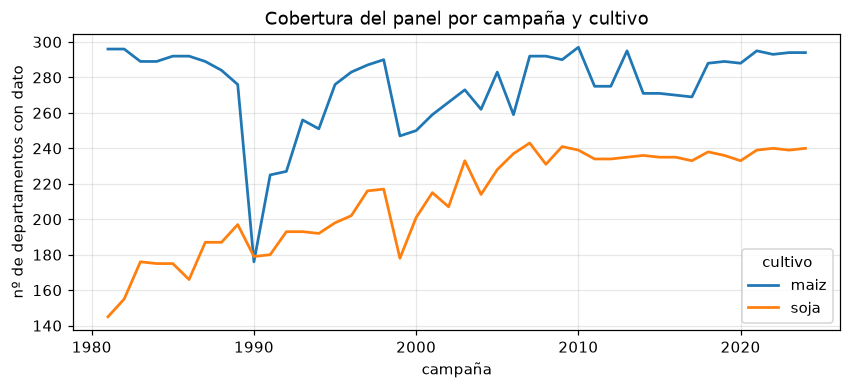

In [3]:
cob = panel.groupby(["campania_inicio","cultivo"]).size().unstack()
fig, ax = plt.subplots(figsize=(9, 3.5))
cob.plot(ax=ax, lw=1.8)
ax.set_xlabel("campaña"); ax.set_ylabel("nº de departamentos con dato")
ax.set_title("Cobertura del panel por campaña y cultivo")
ax.grid(alpha=0.3); plt.show()

La cobertura no es constante: crece a medida que MAGyP incorpora departamentos.
Por eso todo lo que se agrega por campaña (tasas de anomalía, promedios) se calcula
sobre los departamentos **con dato en esa campaña**, y la etiqueta se define por
la historia **propia** de cada serie (no contra un padrón fijo).

---
## 2 · El objetivo: `rinde_kgha`

Dos hechos del rinde definen el diseño de la etiqueta:
1. **Tendencia tecnológica**: el rinde sube secularmente (genética, manejo) → un
   umbral absoluto confundiría "campaña vieja" con "campaña mala".
2. **Heterogeneidad espacial**: la escala de rinde depende del departamento (y del
   cultivo) → cualquier comparación debe ser contra el propio departamento.

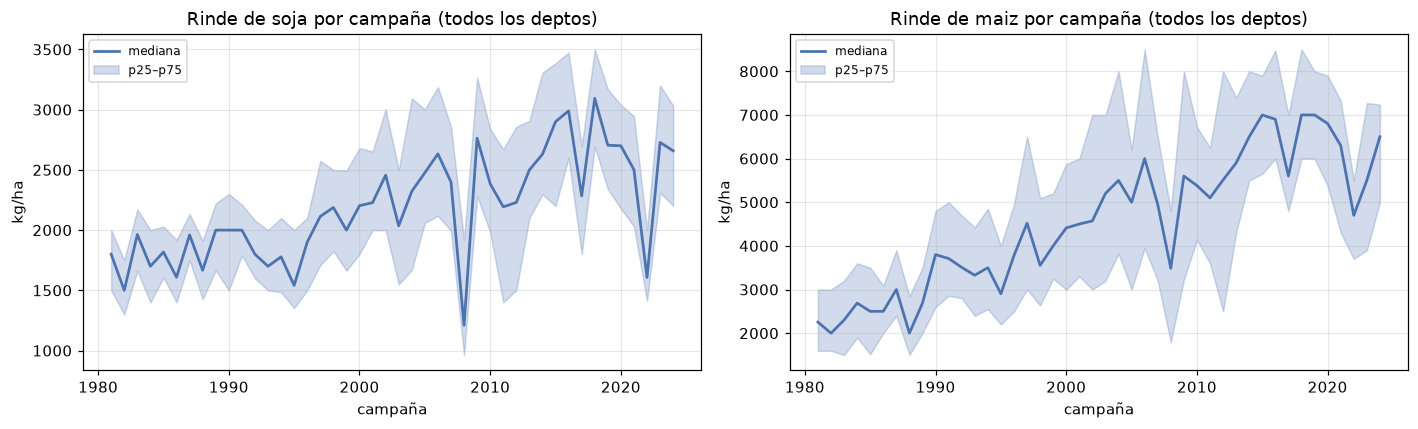

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, cult in zip(axes, ["soja", "maiz"]):
    d = panel[panel.cultivo == cult]
    g = d.groupby("campania_inicio")["rinde_kgha"]
    ax.plot(g.median().index, g.median().values, color="#4C72B0", lw=1.8, label="mediana")
    ax.fill_between(g.median().index, g.quantile(.25), g.quantile(.75),
                    alpha=0.25, color="#4C72B0", label="p25–p75")
    ax.set_title(f"Rinde de {cult} por campaña (todos los deptos)")
    ax.set_xlabel("campaña"); ax.set_ylabel("kg/ha"); ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

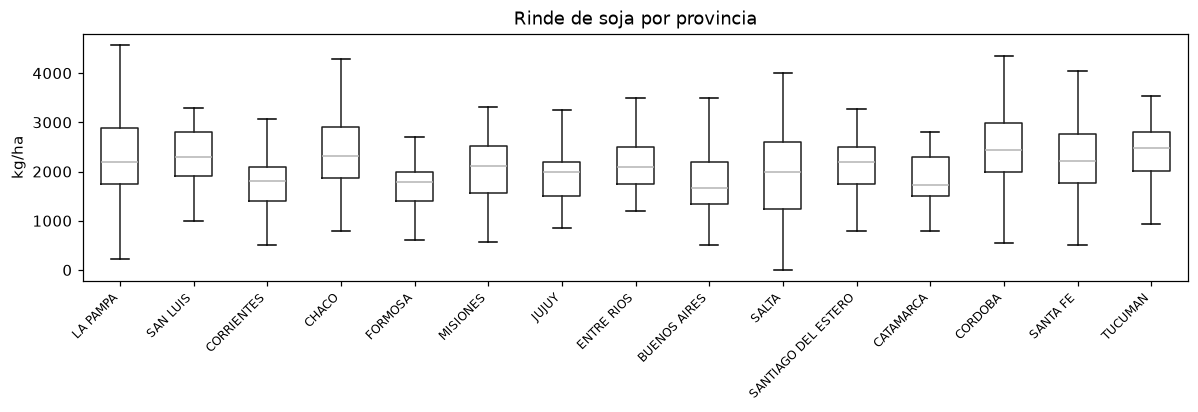

In [5]:
orden = (panel[panel.cultivo=="soja"].groupby("provincia")["rinde_kgha"]
         .median().sort_values().index)
fig, ax = plt.subplots(figsize=(11, 4))
panel[panel.cultivo=="soja"].boxplot(column="rinde_kgha", by="provincia", ax=ax,
                                     positions=range(len(orden)), showfliers=False,
                                     grid=False)   # orden por mediana
ax.set_xticklabels(orden, rotation=45, ha="right", fontsize=8)
ax.set_title("Rinde de soja por provincia"); ax.set_xlabel(""); ax.set_ylabel("kg/ha")
plt.suptitle(""); plt.tight_layout(); plt.show()

La mediana de rinde de soja varía ~2× entre provincias (y más entre
departamentos): la "normalidad" es **local**. Las dos observaciones juntas motivan la
etiqueta como desvío contra la **media móvil del propio (departamento, cultivo)** —
la tendencia queda absorbida por la ventana móvil y la escala por el agrupamiento.

### 2.1 · Un chequeo independiente: % de superficie cosechada
El cociente cosechada/sembrada captura **abandono de lotes** — señal de campaña mala
que no depende del rinde (el rinde se mide sobre lo que sí se cosechó):

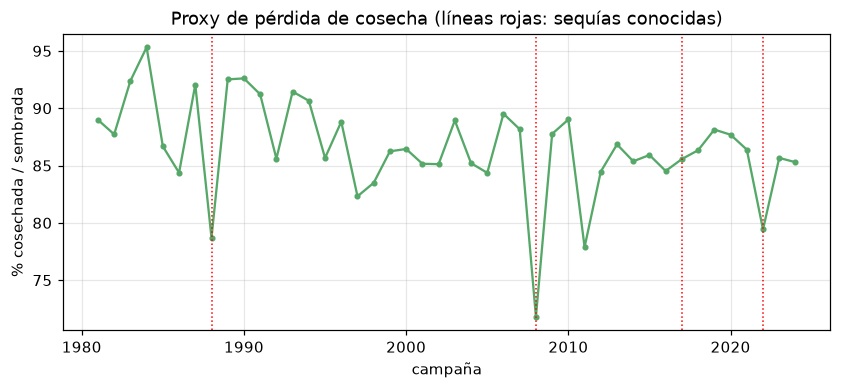

mínimos: {2008: 71.8, 2011: 77.9, 1988: 78.7, 2022: 79.4}


In [6]:
panel["_pct_cosechada"] = panel.sup_cosechada_ha / panel.sup_sembrada_ha * 100
pc = panel.groupby("campania_inicio")["_pct_cosechada"].mean()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(pc.index, pc.values, "-o", ms=3, color="#55A868")
for y in [1988, 2008, 2017, 2022]:
    ax.axvline(y, color="red", ls=":", lw=1)
ax.set_xlabel("campaña"); ax.set_ylabel("% cosechada / sembrada")
ax.set_title("Proxy de pérdida de cosecha (líneas rojas: sequías conocidas)")
ax.grid(alpha=0.3); plt.show()
print("mínimos:", pc.nsmallest(4).round(1).to_dict())

Los mínimos del % cosechado (2008/09 ~72%, 1988/89, 2022/23) coinciden con las
sequías históricas — el panel "ve" los eventos que después le vamos a pedir detectar.

---
## 3 · La etiqueta proxy: `z_rinde < −1.5`

`z_rinde` = desvío del rinde respecto de la media móvil de 5 campañas del propio
(provincia, departamento, cultivo), calculada solo con pasado (`shift(1)`). Es la
**misma** etiqueta que usan todos los modelos (acá la calculamos con la función del
pipeline). Las primeras campañas de cada serie no tienen historia suficiente →
etiqueta indefinida (~8% de filas).

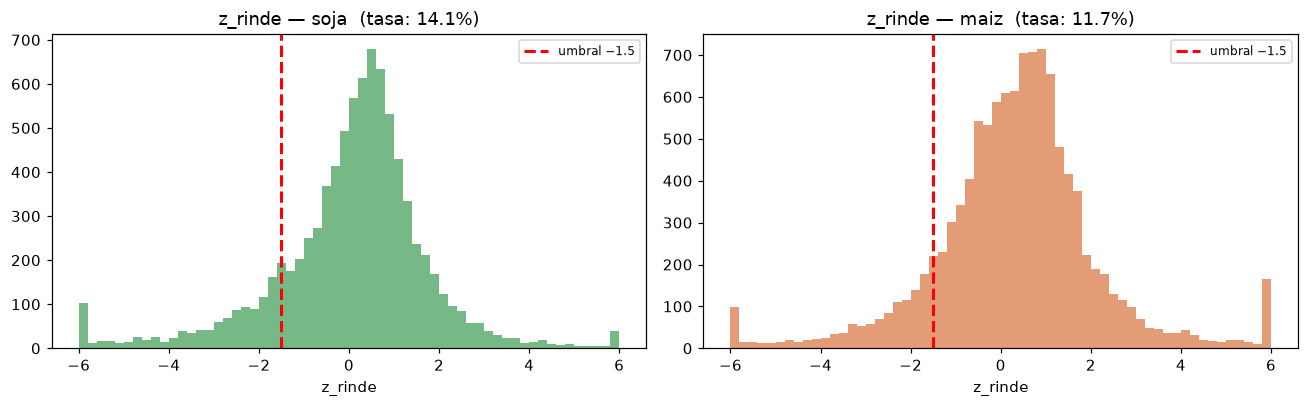

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, cult, color in zip(axes, ["soja", "maiz"], ["#55A868", "#DD8452"]):
    z = panel[panel.cultivo==cult].z_rinde.dropna()
    ax.hist(z.clip(-6, 6), bins=60, color=color, alpha=0.8)
    ax.axvline(-1.5, color="red", ls="--", lw=2, label="umbral −1.5")
    ax.set_title(f"z_rinde — {cult}  (tasa: {(z < -1.5).mean()*100:.1f}%)")
    ax.set_xlabel("z_rinde"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### 3.1 · ¿La etiqueta marca campañas que tienen sentido?

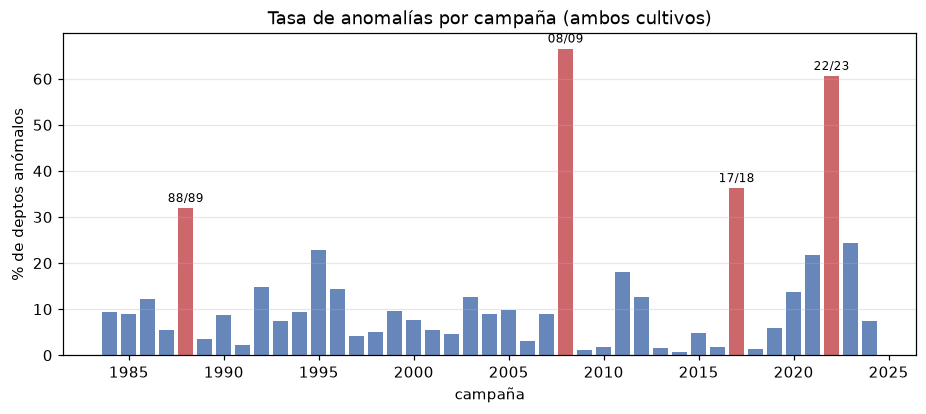

In [8]:
lab = panel[panel.z_rinde.notna()]
tasa = lab.groupby("campania_inicio")["anomalia"].mean() * 100
fig, ax = plt.subplots(figsize=(10, 3.8))
colores = ["#C44E52" if t > 30 else "#4C72B0" for t in tasa]
ax.bar(tasa.index, tasa.values, color=colores, alpha=0.85)
for y, txt in [(1988, "88/89"), (2008, "08/09"), (2017, "17/18"), (2022, "22/23")]:
    ax.annotate(txt, (y, tasa.get(y, 0)), textcoords="offset points",
                xytext=(0, 4), ha="center", fontsize=8)
ax.set_xlabel("campaña"); ax.set_ylabel("% de deptos anómalos")
ax.set_title("Tasa de anomalías por campaña (ambos cultivos)")
ax.grid(axis="y", alpha=0.3); plt.show()

In [9]:
top = (lab.groupby("campania_inicio")
       .agg(n_deptos=("anomalia","size"), n_anomalias=("anomalia","sum"),
            tasa=("anomalia","mean"), z_medio=("z_rinde","median"))
       .sort_values("tasa", ascending=False).head(8))
top["tasa"] = (top["tasa"]*100).round(1)
top.round(2)

,n_deptos,n_anomalias,tasa,z_medio
campania_inicio,,,,
2008,523,348,66.5,-2.26
2022,533,323,60.6,-1.82
2017,502,182,36.3,-0.67
1988,448,143,31.9,-0.86
2023,532,130,24.4,0.00
1995,464,106,22.8,-0.42
2021,534,116,21.7,-0.46
2011,509,92,18.1,-0.18


Las campañas más anómalas son exactamente las sequías documentadas — **2008/09
(66%), 2022/23 (61%), 2017/18 (36%), 1988/89 (32%)** — sin que ninguna información
climática haya entrado en la etiqueta (sale solo del rinde). Es la validación externa
de que el proxy marca eventos reales.

### 3.2 · ¿Dónde? Tasa de anomalía por provincia × campaña

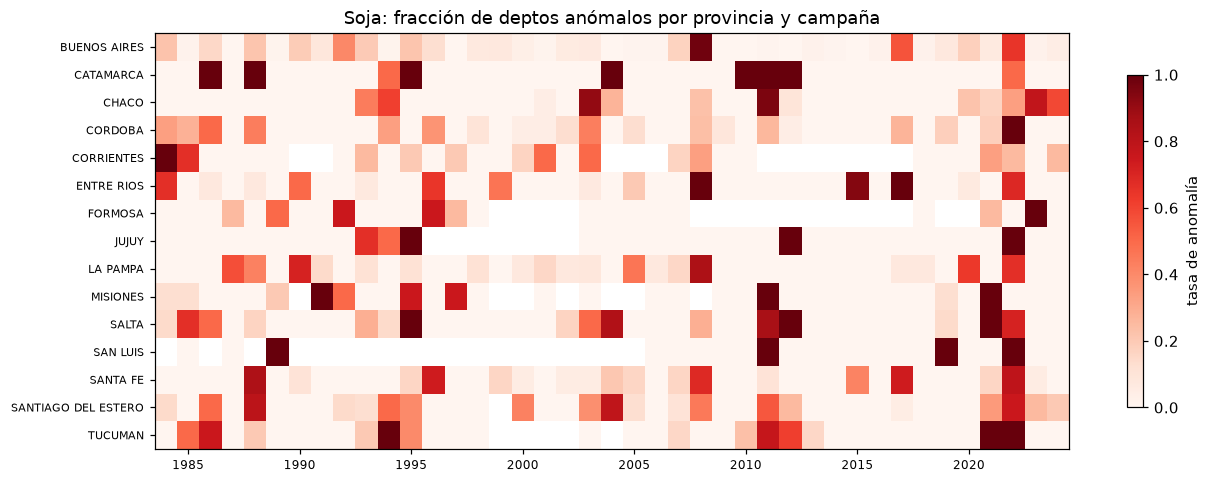

In [10]:
hm = (lab[lab.cultivo=="soja"]
      .pivot_table(index="provincia", columns="campania_inicio",
                   values="anomalia", aggfunc="mean"))
fig, ax = plt.subplots(figsize=(12, 4.5))
im = ax.imshow(hm.values, aspect="auto", cmap="Reds", vmin=0, vmax=1)
ax.set_yticks(range(len(hm.index))); ax.set_yticklabels(hm.index, fontsize=7)
xt = [i for i, c in enumerate(hm.columns) if c % 5 == 0]
ax.set_xticks(xt); ax.set_xticklabels([hm.columns[i] for i in xt], fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8, label="tasa de anomalía")
ax.set_title("Soja: fracción de deptos anómalos por provincia y campaña")
plt.tight_layout(); plt.show()

Las sequías grandes son **franjas verticales** (golpean a casi todas las
provincias a la vez); el resto de las anomalías está disperso — eventos locales.
Esta mezcla de eventos sistémicos + locales es lo que el detector tiene que cubrir.

---
## 4 · ENSO: el driver climático conocido

El ONI (índice El Niño / La Niña) es la única feature *global* del panel (igual para
todos los deptos de una campaña). Chequeo de sanidad: en Argentina, La Niña se asocia
a campañas secas → debería haber más anomalías.

,tasa_anomalia,z_rinde_medio,n
fase,,,
La Niña,0.220,-0.383,7377
Neutro,0.082,0.405,5593
El Niño,0.064,0.757,6766


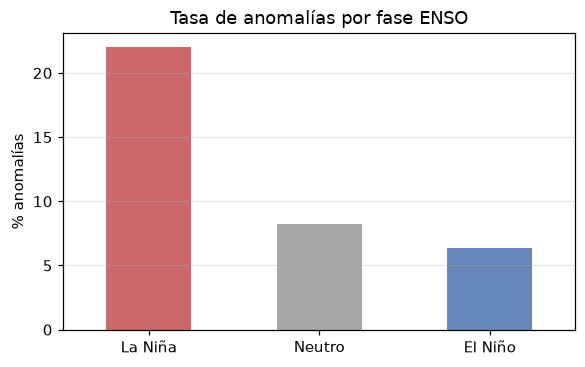

In [11]:
oni_cols = [c for c in panel.columns if c.startswith("oni_")]
lab2 = lab.assign(_oni=lab[oni_cols].mean(axis=1))
lab2["fase"] = pd.cut(lab2._oni, [-9, -0.5, 0.5, 9], labels=["La Niña", "Neutro", "El Niño"])
res = lab2.groupby("fase", observed=True).agg(
    tasa_anomalia=("anomalia", "mean"), z_rinde_medio=("z_rinde", "mean"),
    n=("anomalia", "size")).round(3)
display(res)
fig, ax = plt.subplots(figsize=(6, 3.5))
(res.tasa_anomalia*100).plot.bar(ax=ax, color=["#C44E52", "#999999", "#4C72B0"], alpha=0.85)
ax.set_ylabel("% anomalías"); ax.set_xlabel("")
ax.set_title("Tasa de anomalías por fase ENSO"); ax.tick_params(rotation=0)
ax.grid(axis="y", alpha=0.3); plt.show()

**La Niña triplica la tasa de anomalías** (22% vs 6–8%) y baja el z_rinde medio.
Hay señal climática real en el panel — la pregunta de los experimentos es *cuánta*.

---
## 5 · Las features (54 columnas)

7 variables de NASA POWER × 7 meses de campaña (Sep–Mar) + ONI de 5 meses:
radiación (`allsky`), precipitación (`prectotcorr`), humedad relativa (`rh2m`),
temperatura media/máx/mín (`t2m*`) y viento (`ws2m`). **No incluyen el rinde.**

> Sobre el NDVI del panel: ~45% NaN (MODIS existe desde 2002) y 3 de las 4 columnas
> son constantes por departamento. Se excluye del set base; la evaluación con NDVI
> largo (AVHRR 1981+) está en `experiments/05`.

54 features


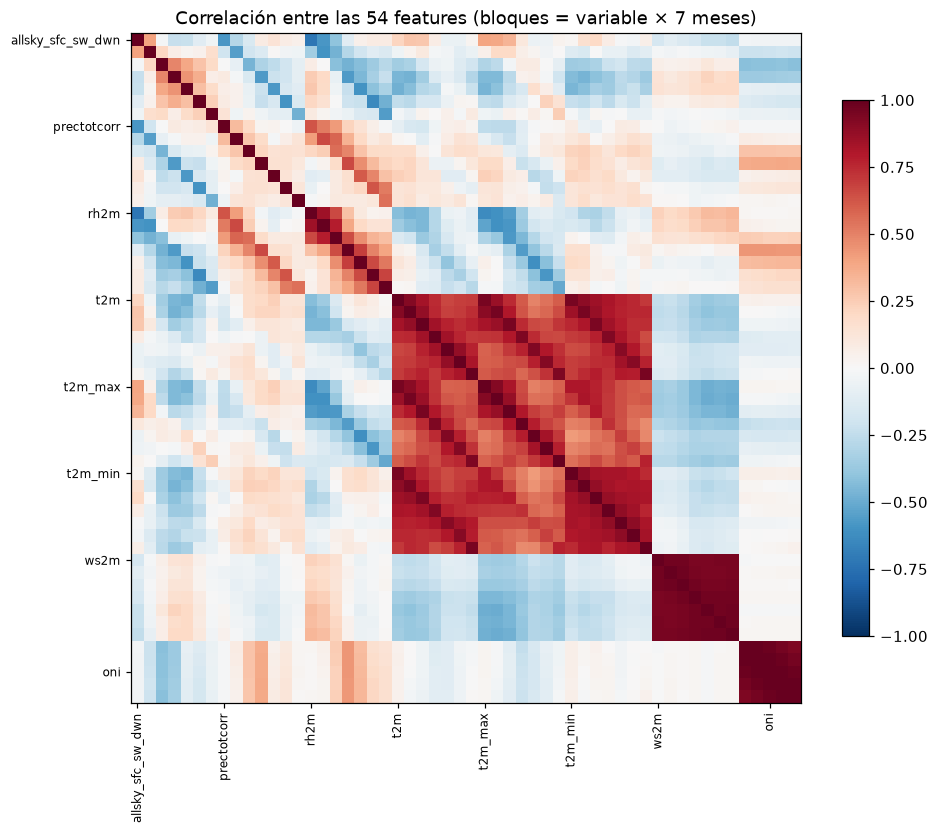

In [12]:
feats = cdata.build_feature_list(panel, use_ndvi=False)
print(f"{len(feats)} features")
corr = panel[feats].corr()
fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1)
marcas = [i for i, f in enumerate(feats) if f.endswith("_sep") or f.startswith("oni_dic")]
ax.set_xticks(marcas); ax.set_yticks(marcas)
etiq = [feats[i].rsplit("_", 1)[0] for i in marcas]
ax.set_xticklabels(etiq, rotation=90, fontsize=8); ax.set_yticklabels(etiq, fontsize=8)
plt.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlación entre las 54 features (bloques = variable × 7 meses)")
plt.tight_layout(); plt.show()

Estructura en bloques esperable: los 7 meses de una misma variable correlacionan
entre sí (sobre todo temperaturas), y las temperaturas entre ellas. El espacio efectivo
tiene bastante menos de 54 dimensiones — coherente con los latentes chicos (8–16) que
terminaron funcionando en los autoencoders.

### 5.1 · ¿Por qué normalizar por departamento?
Para varias variables, la diferencia climática **estructural** entre departamentos es
del orden (o mayor) que la variabilidad **interanual** dentro de cada uno. Donde eso
pasa, un modelo sin normalizar aprendería geografía en lugar de anomalías:

,feature,var_entre_deptos,var_dentro_depto,ratio
0,prectotcorr_ene,0.73,3.77,0.19
1,t2m_max_ene,5.50,2.77,1.98
2,rh2m_ene,30.18,57.93,0.52


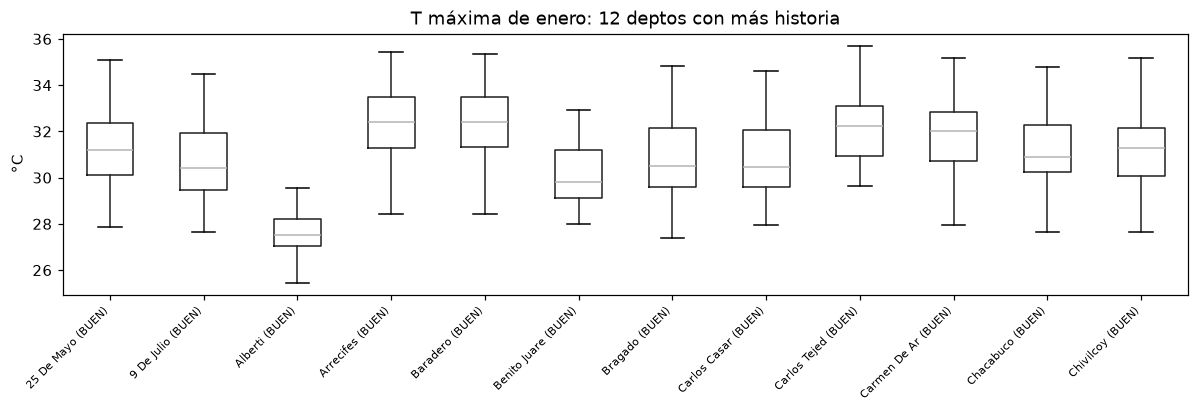

In [13]:
soja = panel[panel.cultivo=="soja"]
filas = []
for f in ["prectotcorr_ene", "t2m_max_ene", "rh2m_ene"]:
    entre = soja.groupby(["provincia","departamento"])[f].mean().var()
    dentro = soja.groupby(["provincia","departamento"])[f].var().mean()
    filas.append((f, entre, dentro, entre/dentro))
display(pd.DataFrame(filas, columns=["feature","var_entre_deptos","var_dentro_depto","ratio"]).round(2))

deps = (soja.groupby(["provincia","departamento"]).size().nlargest(12).index)
d12 = soja.set_index(["provincia","departamento"]).loc[deps].reset_index()
d12["_dep"] = d12.departamento.str[:12] + " (" + d12.provincia.str[:4] + ")"
fig, ax = plt.subplots(figsize=(11, 4))
d12.boxplot(column="t2m_max_ene", by="_dep", ax=ax, grid=False, showfliers=False)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
ax.set_title("T máxima de enero: 12 deptos con más historia"); ax.set_xlabel("")
ax.set_ylabel("°C"); plt.suptitle(""); plt.tight_layout(); plt.show()

El ratio depende de la variable: para **temperatura** el nivel entre departamentos
domina ampliamente (ratio ~2 — los boxplots casi no se solapan), mientras que para
**precipitación** pesa más lo interanual (ratio ~0.2). Como al menos parte de las
features tiene un nivel geográfico fuerte, el pipeline z-scorea **cada feature por
departamento** (con estadísticas de train): así, sea cual sea la variable, lo que el
modelo ve es "qué tan raro fue este año *acá*" y no el nivel de base del lugar.

---
## 6 · ¿Cuánta señal clima → anomalía hay? (soja)

Comparamos las features (normalizadas por depto, solo para explorar) entre campañas
normales y anómalas. Test de Mann-Whitney U + mediana por clase:

In [14]:
from scipy.stats import mannwhitneyu
s = soja[soja.z_rinde.notna()].copy()
s[feats] = s.groupby(["provincia","departamento"])[feats].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() > 0 else x * 0)

clave = ["prectotcorr_dic","prectotcorr_ene","prectotcorr_feb",
         "t2m_max_dic","t2m_max_ene","rh2m_ene","allsky_sfc_sw_dwn_ene","oni_ene"]
filas = []
for f in clave:
    a, n = s[s.anomalia==1][f].dropna(), s[s.anomalia==0][f].dropna()
    p = mannwhitneyu(a, n).pvalue
    filas.append((f, n.median().round(2), a.median().round(2),
                  "***" if p<1e-3 else "**" if p<1e-2 else "*" if p<.05 else "ns"))
pd.DataFrame(filas, columns=["feature","mediana_normal","mediana_anómala","signif"])

,feature,mediana_normal,mediana_anómala,signif
0,prectotcorr_dic,-0.10,-0.62,***
1,prectotcorr_ene,-0.06,-0.60,***
2,prectotcorr_feb,-0.06,-0.59,***
3,t2m_max_dic,-0.11,0.45,***
4,t2m_max_ene,-0.13,0.66,***
5,rh2m_ene,0.08,-0.73,***
6,allsky_sfc_sw_dwn_ene,0.01,0.48,***
7,oni_ene,-0.14,-0.55,***


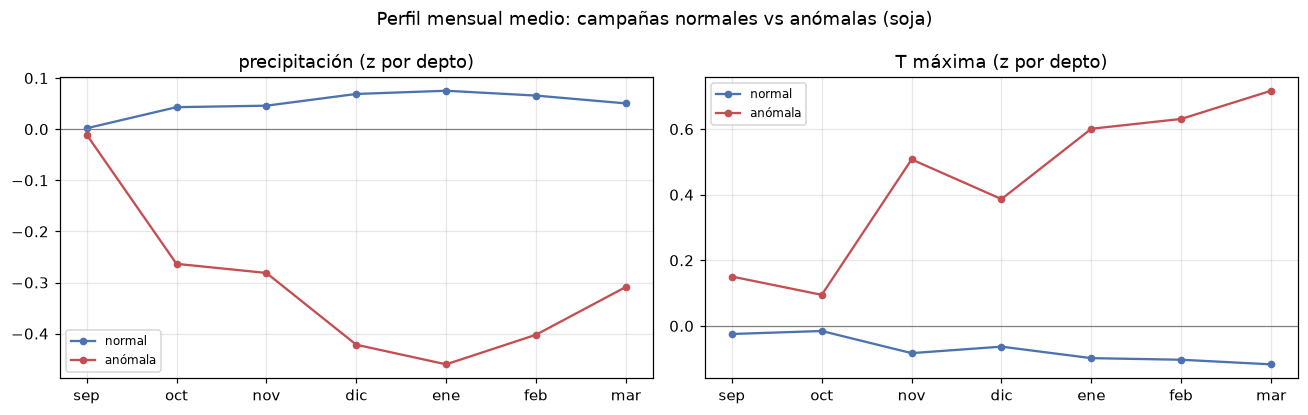

In [15]:
meses = ["sep","oct","nov","dic","ene","feb","mar"]
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8), sharex=True)
for ax, var, tit in [(axes[0], "prectotcorr", "precipitación (z por depto)"),
                     (axes[1], "t2m_max", "T máxima (z por depto)")]:
    for lab_, color, nombre in [(0, "#4C72B0", "normal"), (1, "#C44E52", "anómala")]:
        y = [s[s.anomalia==lab_][f"{var}_{m}"].mean() for m in meses]
        ax.plot(meses, y, "-o", ms=4, color=color, label=nombre)
    ax.axhline(0, color="gray", lw=0.8); ax.set_title(tit)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.suptitle("Perfil mensual medio: campañas normales vs anómalas (soja)")
plt.tight_layout(); plt.show()

Hay señal — las campañas anómalas son en promedio **más secas y más calurosas en
Dic–Feb** (el período crítico de la soja) — pero es un corrimiento de **décimas de
desvío estándar en el promedio**, con distribuciones muy solapadas. Traducción: el
clima separa *en promedio*, no caso por caso. Esto anticipa el resultado central de
los experimentos (el "techo estructural", `experiments/04`): una parte grande de las
anomalías de rinde no tiene firma climática individual.

---
## 7 · Splits temporales y *distribution shift*

Train ≤2017/18, val 2018–2020, test 2021+ (simula detectar campañas futuras).

In [16]:
res = (lab.groupby(["split","cultivo"])["anomalia"]
       .agg(n="size", tasa="mean").reset_index())
res["tasa"] = (res.tasa*100).round(1)
display(res.pivot(index="split", columns="cultivo", values=["n","tasa"])
        .reindex(["train","val","test"]))

n          tasa      
cultivo    maiz    soja  maiz  soja
split                              
train    9135.0  6897.0   9.8  13.0
val       865.0   707.0   7.4   6.4
test     1174.0   958.0  29.9  26.9

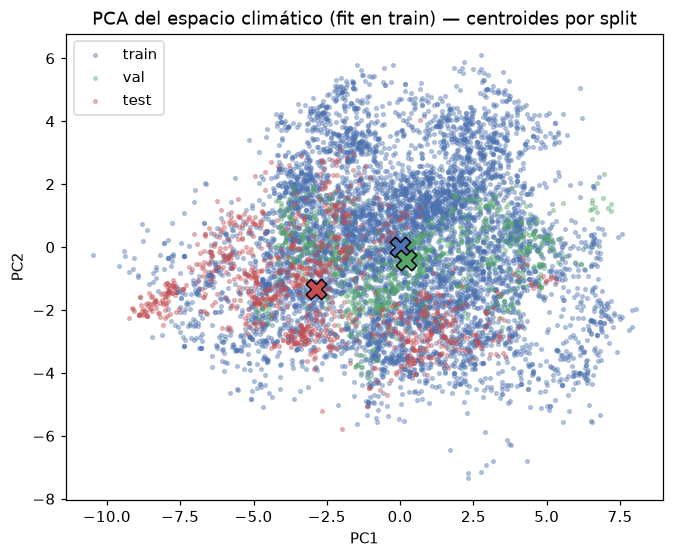

varianza explicada PC1+PC2: 0.29


In [17]:
from sklearn.decomposition import PCA
sl = soja[soja.z_rinde.notna()].copy()
sl[feats] = sl.groupby(["provincia","departamento"])[feats].transform(
    lambda x: (x - x.mean()) / x.std() if x.std() > 0 else x * 0)
sl = sl.dropna(subset=feats)
pca = PCA(n_components=2, random_state=42).fit(sl[sl.split=="train"][feats])
emb = pca.transform(sl[feats])
fig, ax = plt.subplots(figsize=(7, 5.5))
for sp, color in [("train","#4C72B0"), ("val","#55A868"), ("test","#C44E52")]:
    m = (sl.split==sp).values
    ax.scatter(emb[m,0], emb[m,1], s=6, alpha=0.35, color=color, label=sp)
    mx, my = emb[m,0].mean(), emb[m,1].mean()
    ax.scatter([mx],[my], s=180, marker="X", color=color, edgecolor="k", zorder=5)
ax.legend(); ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("PCA del espacio climático (fit en train) — centroides por split")
plt.show()
print("varianza explicada PC1+PC2:", pca.explained_variance_ratio_.sum().round(2))

Dos hechos que condicionan toda la evaluación (ver `experiments/01`):
- **La tasa base de anomalías cambia de split**: ~7% en val vs ~29% en test (la sequía
  2022/23 cae en test). Un umbral calibrado en val no puede transferir.
- **El clima de test está corrido** respecto de train (centroides desplazados en el
  PCA): los scores absolutos suben en bloque → solo las métricas de *ranking*
  (PR-AUC/ROC-AUC) son comparables entre splits.

---
## 8 · Conclusiones del EDA → decisiones de diseño

| hallazgo | decisión de diseño |
|---|---|
| Rinde con tendencia secular y escala local (§2) | etiqueta = z-score vs **media móvil** del propio (provincia, depto, cultivo) |
| La etiqueta marca las sequías documentadas y el % cosechado las confirma (§3) | el proxy `z_rinde < −1.5` es válido como ground truth de evaluación |
| Nivel climático geográfico fuerte en varias features (temp. ratio ~2) (§5.1) | **normalización por departamento** con stats de train |
| Features en bloques redundantes (§5) | latentes chicos (8–16) en los autoencoders |
| Señal clima→anomalía real (Niña 3×) pero solapada caso a caso (§4, §6) | esperar recall alto en anomalías climáticas y un techo en las demás (`experiments/04`) |
| Tasa base y clima cambian de split (§7) | métricas de ranking (PR-AUC), umbral re-calibrado por split (`experiments/01`) |

El modelado a partir de acá: **`experiments/00–06`**.